<a href="https://colab.research.google.com/github/athirasivadas94-glitch/EntriAssignments/blob/main/Assignment_Linear_Algebra_and_Probability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this assignment, you will apply Linear Algebra and Probability techniques to analyze the Wine
Quality Dataset. The dataset consists of 1599 rows and 12 columns, detailing various chemical
properties of red and white wines and their quality scores. Your tasks will focus on vectors,
matrices, eigenvalues, eigenvectors, and basic probability concepts. You can download the
dataset from the link given below. The dataset contains 1599 samples of wine, with features
such as acidity, alcohol content, pH, residual sugar, and others, alongside the target variable,
wine quality

1. Load the dataset and handle any missing data by replacing null values with the mean value of the respective column.

In [ ]:
import pandas as pd
import numpy as np
#Read data from file
data = pd.read_csv("winequality-red.csv",sep=';')
data.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
#Checking for null values
data.isnull().sum()

#Replacing null with column mean
data = data.fillna(data.mean())

data.isnull().sum()



,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


2. Extract the following columns as vectors: alcohol,citric acid

In [ ]:
#Alcohol
alcohol_vector = data['alcohol'].values
alcohol_vector
alcohol_vector.shape

(1599,)

In [ ]:
#citric acid
citric_acid_vector = data['citric acid'].values
citric_acid_vector
alcohol_vector.shape

(1599,)

3. Select two features (e.g., alcohol and density) from the dataset and calculate the covariance matrix using np.cov(X.T), where X is the feature matrix consisting of the selected columns

In [ ]:
X = data[['alcohol', 'density']].values
X.shape


(1599, 2)

In [ ]:
#Covarience
cov_matrix = np.cov(X.T)
print(cov_matrix)

[[ 1.13564740e+00 -9.97951790e-04]
 [-9.97951790e-04  3.56202945e-06]]


4. Perform eigen decomposition on the covariance matrix you computed in question 3.Identify and interpret the results:Identify the top 2 eigenvalues of the covariance matrix,Identify the corresponding eigenvectors

In [ ]:
#Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("Eigenvalues:\n", eigenvalues)
print("\nEigenvectors:\n", eigenvectors)


Eigenvalues:
 [1.13564827e+00 2.68507580e-06]

Eigenvectors:
 [[ 9.99999614e-01  8.78753184e-04]
 [-8.78753184e-04  9.99999614e-01]]


In [ ]:
idx = np.argsort(eigenvalues)[::-1]

top_eigenvalues = eigenvalues[idx]
top_eigenvectors = eigenvectors[:, idx]

print("Top 2 Eigenvalues:\n", top_eigenvalues)
print("\nCorresponding Eigenvectors:\n", top_eigenvectors)

Top 2 Eigenvalues:
 [1.13564827e+00 2.68507580e-06]

Corresponding Eigenvectors:
 [[ 9.99999614e-01  8.78753184e-04]
 [-8.78753184e-04  9.99999614e-01]]


Eigen value 1  is very large compared to Eigen value 2, indicating that almost all the variance in the data lies along the first principal direction.

Eigenvalue 2 is extremely small, meaning there is very little variance in the second direction.

This suggests that the two features (alcohol and density) are highly correlated and the data is effectively one-dimensional.

The first eigenvector is dominated by the alcohol component, indicating that alcohol content explains nearly all the variation.

The small negative value for density shows a slight inverse relationship between alcohol and density.

The second eigenvector is almost entirely aligned with density, but since its eigenvalue is very small, this direction contributes negligible information.

5. Which wine quality is most common in the dataset? How can you interpret the
distribution of wine quality scores?

In [ ]:
mode_quality = data['quality'].mode()
print(mode_quality)

0    5
Name: quality, dtype: int64


Mode of wine quality = 5

This means quality score 5 occurs most frequently in the dataset.

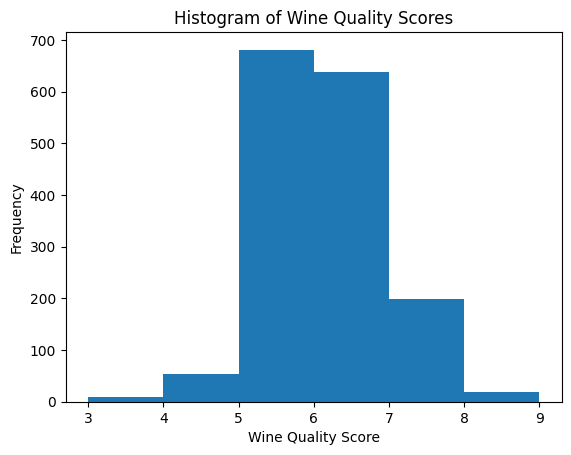

In [ ]:
import matplotlib.pyplot as plt

# Histogram
plt.figure()
plt.hist(data['quality'], bins=range(data['quality'].min(), data['quality'].max() + 2))
plt.xlabel("Wine Quality Score")
plt.ylabel("Frequency")
plt.title("Histogram of Wine Quality Scores")
plt.show()